# 元回归与调节变量:异质性从哪来

上一本([22 · Meta 分析入门](22_meta_analysis_basics.ipynb))里,卡介苗数据的 I² 高达 92%——
合并出的「平均保护效应」下面藏着巨大的研究间差异。**高 I² 不是终点,而是问题的开始:差异
究竟从哪来?** 是纬度?是年代?是随机噪声?**元回归(meta-regression)** 就是回答这个问题的
工具:把研究层面的**调节变量(moderator)** 放进一个混合效应回归,看它能不能解释掉一部分 τ²。

这本 notebook 走一条完整的调节变量分析链,每一步都对应一个真实的方法学决策:

1. **效应量家族**:同一个「效应」有很多条路——2×2、均值/标准差、t 值、相关 r 都能算成可比效应量;
   我们演示 `es_from_means → hedges` 与 `es_convert`(SMD↔r)的换算桥;
2. **连续调节变量**:`metareg` 用**纬度 ablat** 解释卡介苗异质(著名地复现 metafor:纬度解释 ~75%);
3. **多个调节变量必做 FDR**:`metareg_fdr` 给综合 QM 检验 + Benjamini-Hochberg 校正——多重比较不校正就是 p-hacking;
4. **离散调节变量**:`subgroup` 做亚组合并 + 组间异质 `Q_between`;
5. **小 k 更诚实**:`metareg_permutest` 用置换检验取代依赖大样本近似的 QM;
6. **探索非线性/交互**:`metaforest`(随机森林元回归)给方向性的变量重要性;
7. **模型不确定性**:`metareg_multimodel` 全子集 AICc + Akaike 权重,给稳健的变量重要性;
8. **嵌套模型检验**:`ma_lrt` 似然比检验含/不含调节变量的模型。

> **对标**:R `metafor`(`rma(mods=~ablat)`)/ `metaforest` / `MuMIn`(多模型平均)/ `clubSandwich`。

关键前提贯穿全篇:**元回归是观测性的**——纬度和年代、人群高度共线,「解释」不等于「因果」;
调节变量应尽量**事先登记**;研究数少时(这里 k=13)自由度紧张,`metareg_permutest` 比正态近似更可信。

In [1]:
import os
import sys

# 确保用的是本 worktree 里的 socialverse(而不是环境里 editable 安装指向的其它 checkout)
try:
    _HERE = os.path.dirname(os.path.abspath(__file__))
except NameError:  # 在 Jupyter cell 里没有 __file__,退回当前工作目录
    _HERE = os.path.abspath(os.getcwd())
_ROOT = os.path.dirname(_HERE) if os.path.basename(_HERE) == "notebooks" else _HERE
if os.path.isdir(os.path.join(_ROOT, "socialverse")) and _ROOT not in sys.path:
    sys.path.insert(0, _ROOT)

import matplotlib
matplotlib.use("Agg")  # 无显示环境:图直接写文件
import matplotlib.pyplot as plt
from matplotlib import font_manager as _fm
import numpy as np
import pandas as pd
from IPython.display import Image

import socialverse as sv
from socialverse import datasets as ds

# 让本 notebook 自绘的图也能显示中文标签
_CJK = ["PingFang SC", "Hiragino Sans GB", "Songti SC", "STHeiti",
        "Arial Unicode MS", "Noto Sans CJK SC", "Microsoft YaHei"]
_have = {f.name for f in _fm.fontManager.ttflist}
plt.rcParams["font.sans-serif"] = [c for c in _CJK if c in _have] + ["DejaVu Sans"]
plt.rcParams["axes.unicode_minus"] = False

print("socialverse", sv.__version__)

socialverse 0.6.0


## 1. 效应量家族:通往同一个效应的几条路

**要解决的问题**:各研究报告的原始统计量五花八门——有的给 2×2 计数,有的给两组均值+标准差,
有的只报了 t 值或相关系数 r。元回归的输入必须是**统一的 (yi, vi)**:一个可比的效应量 + 它的
抽样方差。`escalc` 家族把每条路都铺好了(对标 `metafor::escalc` 的 `measure=`):

| 原始数据 | 函数 | 度量 |
|---|---|---|
| 2×2 计数 | `es_from_2x2` | `OR`/`RR`/`RD` |
| 均值/标准差 | `es_from_means` | `SMD`(Cohen's d) |
| t 值 | `es_from_t` | `SMD` |
| 相关 r | `es_from_r` | `ZCOR`(Fisher z) |

**关键前提**:不同度量之间可以近似互换(基于分布假设的换算桥),这样一份 meta 里混合来源的
研究能被拉到同一尺度。下面用一个最小例子演示两个换算:`es_from_means → hedges_correct`
(SMD 的小样本校正)和 `es_convert`(把 SMD 换算成相关 r)。

In [2]:
# 一个两研究的玩具连续结局表:干预 vs 对照的均值/标准差/样本量
demo = pd.DataFrame({
    "study": ["A", "B"],
    "m1": [12.0, 10.5], "sd1": [3.0, 2.8], "n1": [20, 18],
    "m2": [10.0,  9.0], "sd2": [3.2, 2.6], "n2": [22, 19],
})
sdemo = sv.StudyState()
sdemo.write("sources", "datasets", demo)

# 路①:均值/标准差 → 未校正 SMD(Cohen's d)
sv.pp.es_from_means(sdemo, m1="m1", sd1="sd1", n1="n1", m2="m2", sd2="sd2", n2="n2",
                    study="study", moderators=["n1", "n2"], hedges=False)
d_raw = sdemo.models["meta_effects"][["study", "yi", "vi", "measure"]].copy()

# 对已算好的 SMD 施加 Hedges J 小样本校正(用 n1/n2 推 df)→ Hedges g
sv.pp.hedges_correct(sdemo)
g = sdemo.models["meta_effects"][["study", "yi", "vi", "measure"]].copy()

print("未校正 Cohen's d:")
print(d_raw.round(4).to_string(index=False))
print("\nHedges J 校正后(measure=SMDH,|g| 略小于 |d|,更保守):")
print(g.round(4).to_string(index=False))

未校正 Cohen's d:
study     yi     vi measure
    A 0.6438 0.1004     SMD
    B 0.5558 0.1124     SMD

Hedges J 校正后(measure=SMDH,|g| 略小于 |d|,更保守):
study     yi     vi measure
    A 0.6316 0.0966    SMDH
    B 0.5438 0.1076    SMDH


**换算桥:SMD ↔ 相关 r**。同一个组间差异既能表达成标准化均差,也能表达成点二列相关。
`es_convert(to="ZCOR")` 用 d↔r 桥常数(等组假设 a=4)把 SMD 换成 Fisher z,并用 delta 方法
换算方差——这样一份混合了「均值差研究」和「相关研究」的 meta 才能合并到同一尺度。

In [3]:
sv.tl.es_convert(sdemo, to="ZCOR")   # SMDH → Fisher z(ZCOR)
z = sdemo.models["meta_effects"][["study", "yi", "vi", "measure"]].copy()
print("换算成 Fisher z(ZCOR)后:")
print(z.round(4).to_string(index=False))
print("\n→ 反变换回相关 r:", np.round(np.tanh(z["yi"].to_numpy()), 4))
print("同一个效应,三种坐标(d / g / r)——这就是效应量家族:条条大路通同一个效应。")

换算成 Fisher z(ZCOR)后:
study     yi    vi measure
    A 0.3108 0.022    ZCOR
    B 0.2686 0.025    ZCOR

→ 反变换回相关 r: [0.3012 0.2624]
同一个效应,三种坐标(d / g / r)——这就是效应量家族:条条大路通同一个效应。


**效应量家族速查:论文报什么,就从什么反推**。实证论文常常只给检验统计量(t/F/χ²/p)、一个
相关系数、一段置信区间、或单臂的均值——`socialverse` 为每种情形都备了转换器,最后都汇到统一的
`(yi, vi)`。下面把常见入口各跑一遍(每个用一张最小表),`sv.pp.escalc` 则是按 `measure=` 路由的
总入口。有了它,一份「有的报 t、有的报 OR、有的报 r」的异质文献才能合并到同一把尺子上。

In [4]:
_es_demos = [
    ("es_from_t",         dict(t="t", n1="n1", n2="n2"),                              pd.DataFrame({"t": [2.3], "n1": [30], "n2": [30]})),
    ("es_from_f",         dict(f="f", n1="n1", n2="n2", sign="sign"),                 pd.DataFrame({"f": [5.29], "n1": [30], "n2": [30], "sign": [1]})),
    ("es_from_chisq",     dict(chisq="x2", n="n"),                                    pd.DataFrame({"x2": [8.0], "n": [100]})),
    ("es_from_p",         dict(p="p", n="n"),                                         pd.DataFrame({"p": [0.01], "n": [100]})),
    ("es_from_r",         dict(r="r", n="n"),                                         pd.DataFrame({"r": [0.30], "n": [80]})),
    ("es_from_ci",        dict(est="est", lower="lo", upper="hi"),                    pd.DataFrame({"est": [0.50], "lo": [0.20], "hi": [0.80]})),
    ("es_single_mean",    dict(mean="m", sd="sd", n="n"),                             pd.DataFrame({"m": [10.0], "sd": [2.0], "n": [50]})),
    ("es_ratio_of_means", dict(m1="m1", sd1="sd1", n1="n1", m2="m2", sd2="sd2", n2="n2"), pd.DataFrame({"m1": [10.], "sd1": [2.], "n1": [50], "m2": [8.], "sd2": [2.], "n2": [50]})),
    ("cohens_h",          dict(p1="p1", p2="p2", n1="n1", n2="n2"),                   pd.DataFrame({"p1": [0.30], "p2": [0.20], "n1": [100], "n2": [100]})),
    ("pointbiserial_to_d", dict(r="r", n1="n1", n2="n2"),                             pd.DataFrame({"r": [0.30], "n1": [50], "n2": [50]})),
]
print(f"{'转换器 (sv.pp.*)':24s} {'measure':8s} {'yi':>10s}")
for name, kw, frame in _es_demos:
    st = sv.StudyState(); st.write("sources", "datasets", frame)
    getattr(sv.pp, name)(st, **kw)
    row = st.models["meta_effects"].iloc[0]
    print(f"{name:24s} {row['measure']:8s} {row['yi']:>10.4f}")

# escalc 总入口:按 measure= 路由到上面对应的转换器
st = sv.StudyState(); st.write("sources", "datasets",
    pd.DataFrame({"m1": [12.], "sd1": [3.], "n1": [20], "m2": [10.], "sd2": [3.], "n2": [22]}))
sv.pp.escalc(st, measure="SMD", m1="m1", sd1="sd1", n1="n1", m2="m2", sd2="sd2", n2="n2")
print("\nsv.pp.escalc(measure='SMD') 总入口 → yi =",
      round(float(st.models["meta_effects"]["yi"].iloc[0]), 4))

转换器 (sv.pp.*)            measure          yi
es_from_t                SMD          0.5939
es_from_f                SMD          0.5939
es_from_chisq            ZCOR         0.2908


es_from_p                ZCOR         0.2635
es_from_r                ZCOR         0.3095
es_from_ci               GEN          0.5000
es_single_mean           MN          10.0000
es_ratio_of_means        ROM          0.2231
cohens_h                 COHENH       0.2320
pointbiserial_to_d       SMD          0.6290

sv.pp.escalc(measure='SMD') 总入口 → yi = 0.6667


## 2. 主数据:卡介苗试验 + 纬度调节变量

**要解决的问题**:回到那份 I²=92% 的卡介苗数据,正式问「异质从哪来」。先把 13 项试验的 2×2 表
算成 log 风险比,并把两个候选调节变量带进效应量表:绝对纬度 `ablat`(度)和发表年份 `year`。
`es_from_2x2` 是 2×2 结局的直接入口(等价于 `escalc(measure="RR")`)。

In [5]:
bcg = ds.load_bcg()
study = sv.StudyState()
study.write("sources", "datasets", bcg)

sv.pp.es_from_2x2(study, measure="RR",
                  ai="tpos", bi="tneg", ci="cpos", di="cneg",
                  study="trial", slab="trial", moderators=["ablat", "year"])

eff = study.models["meta_effects"]
print("k =", len(eff), "项试验;效应量 = log 风险比(RR)")
eff[["slab", "yi", "vi", "ablat", "year"]].round(4)

k = 13 项试验;效应量 = log 风险比(RR)


,slab,yi,vi,ablat,year
0,Trial 1,-0.8893,0.3256,44,1948
1,Trial 2,-1.5854,0.1946,55,1949
2,Trial 3,-1.3481,0.4154,42,1960
3,Trial 4,-1.4416,0.0200,52,1977
4,Trial 5,-0.2175,0.0512,13,1973
5,Trial 6,-0.7861,0.0069,44,1953
6,Trial 7,-1.6209,0.2230,19,1973
7,Trial 8,0.0120,0.0040,13,1980
8,Trial 9,-0.4694,0.0564,27,1968
9,Trial 10,-1.3713,0.0730,42,1961


先做一个无调节变量的随机效应基线,拿到「要被解释掉的」总异质 τ²/I²——这是元回归的对照点。

In [6]:
sv.tl.meta_random(study, method="REML")
sv.tl.meta_heterogeneity(study)
het = study.diagnostics["heterogeneity"]
re = study.models["meta"]
print(f"随机效应基线  log-RR = {re['estimate']:.4f}   τ² = {re['tau2']:.4f}")
print(f"总异质        I² = {het['I2']:.1f}%   Q = {het['Q']:.1f} (p = {het['Q_pval']:.1e})")
print("→ 92% 的离散是研究间真实差异。下面看纬度能解释掉多少。")

随机效应基线  log-RR = -0.7145   τ² = 0.3132
总异质        I² = 92.2%   Q = 152.2 (p = 2.0e-26)
→ 92% 的离散是研究间真实差异。下面看纬度能解释掉多少。


## 3. 元回归:纬度解释异质(复现 metafor 的经典结果)

**要解决的问题**:把绝对纬度 `ablat` 作为连续调节变量放进混合效应元回归 `yi ~ 1 + ablat`。
**关键前提**:调节变量是**研究层面**的(每项研究一个纬度值),回归用 τ² 加权(REML),斜率检验
用的是研究间的残余方差而非被试数。**哪几步**:拟合 → 读斜率的符号与显著性 → 看伪-R²(τ² 被解释掉的比例)。

这是 meta 分析教科书里最著名的结果之一:纬度越高(越冷),卡介苗越有效——斜率显著为负,
且解释了约 **75%** 的研究间异质。

In [7]:
sv.tl.metareg(study, moderators=["ablat"])
mr = study.models["metareg"]
b = mr["coefs"]["ablat"]
print(f"斜率 β(ablat) = {b['estimate']:.4f}   SE = {b['se']:.4f}   z = {b['zval']:.2f}   p = {b['pval']:.2e}")
print(f"截距         = {mr['coefs']['(intercept)']['estimate']:.4f}")
print(f"残余 τ²       = {mr['tau2_residual']:.4f}   (基线 τ² = {mr['tau2_null']:.4f})")
print(f"伪-R²         = {mr['R2']:.1f}%   ← 纬度解释掉的研究间异质比例")
print("\n→ 纬度每高 1 度,log-RR 下降约 %.4f:越冷的地区卡介苗保护越强(复现 metafor)。" % b["estimate"])

斜率 β(ablat) = -0.0291   SE = 0.0072   z = -4.04   p = 5.24e-05
截距         = 0.2515
残余 τ²       = 0.0763   (基线 τ² = 0.3132)
伪-R²         = 75.6%   ← 纬度解释掉的研究间异质比例

→ 纬度每高 1 度,log-RR 下降约 -0.0291:越冷的地区卡介苗保护越强(复现 metafor)。


### 元回归气泡图:亲眼看到那条负斜率

每个气泡是一项试验(x = 纬度,y = log-RR,气泡大小 ∝ 权重 1/vi),红线是加权回归拟合。
纬度轴从左到右升高,效应量整体下滑——这就是「纬度解释异质」的可视化。

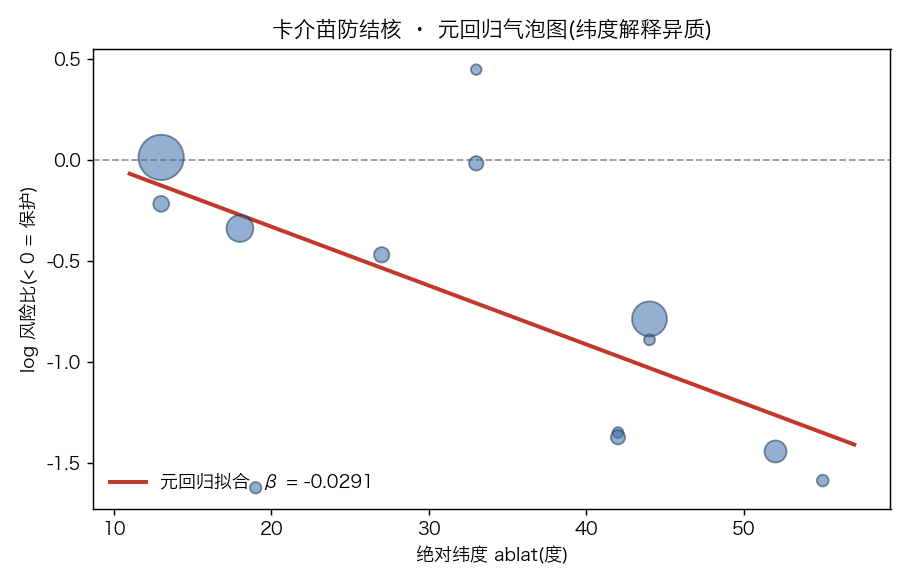

In [8]:
yi = eff["yi"].to_numpy(float)
vi = eff["vi"].to_numpy(float)
ablat = eff["ablat"].to_numpy(float)
w = 1.0 / vi
ic = mr["coefs"]["(intercept)"]["estimate"]
sl = mr["coefs"]["ablat"]["estimate"]

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.scatter(ablat, yi, s=w / w.max() * 600 + 30, alpha=0.55,
           color="#3b6fb0", edgecolor="#20364f", zorder=3)
xs = np.linspace(ablat.min() - 2, ablat.max() + 2, 100)
ax.plot(xs, ic + sl * xs, color="#c0392b", lw=2.2, zorder=2,
        label=f"元回归拟合  β = {sl:.4f}")
ax.axhline(0, color="0.6", lw=1, ls="--", zorder=1)
ax.set_xlabel("绝对纬度 ablat(度)")
ax.set_ylabel("log 风险比(< 0 = 保护)")
ax.set_title("卡介苗防结核 · 元回归气泡图(纬度解释异质)")
ax.legend(loc="lower left", frameon=False)
fig.tight_layout()
fig.savefig("fig24_bubble.png", dpi=130)
plt.close(fig)
Image("fig24_bubble.png")

## 4. 多个调节变量 → 必做 BH-FDR

**要解决的问题**:现实里我们往往同时试好几个调节变量(这里:纬度 + 年份)。**关键前提**:每多
检验一个调节变量,就多一次假阳性机会——**不校正的多重检验就是 p-hacking**。`metareg_fdr` 先给
一个**综合 QM 检验**(所有调节变量联合是否有效),再对各调节变量的 p 值做 **Benjamini-Hochberg FDR**
校正。**哪几步**:先 `metareg` 拟合含全部调节变量的模型 → 再 `metareg_fdr` 读它做 QM + FDR。

In [9]:
sv.tl.metareg(study, moderators=["ablat", "year"])
sv.tl.metareg_fdr(study, alpha=0.05)
fdr = study.diagnostics["metareg_fdr"]
print(f"综合 QM = {fdr['QM']:.2f}  (df = {fdr['QM_df']}, p = {fdr['QM_pval']:.2e})  ← 调节变量整体显著")
print("\n各调节变量(原始 p → BH-FDR 校正 p):")
for name, r in fdr["per_moderator"].items():
    flag = "✓ 显著" if r["significant_fdr"] else "  n.s."
    print(f"  {name:8s}  p = {r['pval']:.4f}   p_FDR = {r['pval_fdr']:.4f}   {flag}")
print("\n→ 纬度 FDR 后仍显著;年份被纬度解释掉后不再独立贡献(两者共线,别过度解读)。")

综合 QM = 7.51  (df = 2, p = 2.34e-02)  ← 调节变量整体显著

各调节变量(原始 p → BH-FDR 校正 p):
  ablat     p = 0.0062   p_FDR = 0.0124   ✓ 显著
  year      p = 0.8966   p_FDR = 0.8966     n.s.

→ 纬度 FDR 后仍显著;年份被纬度解释掉后不再独立贡献(两者共线,别过度解读)。


## 5. 离散调节变量:亚组分析 + Q_between

**要解决的问题**:调节变量若是**分类**的(不是连续数值),元回归斜率就不合适,该做**亚组分析**——
在每个亚组内单独做随机效应合并,再用**组间异质 `Q_between`** 检验各亚组的合并效应是否真的不同
(等价于把亚组当哑变量的 QM 检验)。**哪几步**:把纬度按中位数切成「高纬 / 低纬」离散标签 →
`subgroup(moderator=...)` 逐组合并 + Q_between。

In [10]:
lat_group = np.where(eff["ablat"].to_numpy(float) >= np.median(eff["ablat"]),
                     "高纬(≥中位)", "低纬(<中位)")
eff2 = eff.copy()
eff2["lat_group"] = lat_group
study.write("models", "meta_effects", eff2)   # 把带分组列的效应量表写回

sv.tl.subgroup(study, moderator="lat_group", method="REML")
sg = study.diagnostics["subgroup"]
print("按纬度高低的亚组随机效应合并:")
for g, r in sg["groups"].items():
    print(f"  {g:12s}  k = {r['k']}   log-RR = {r['estimate']:+.4f}   "
          f"95% CI [{r['ci_lb']:+.3f}, {r['ci_ub']:+.3f}]   (RR = {np.exp(r['estimate']):.2f})")
print(f"\nQ_between = {sg['Q_between']:.2f}  (df = {sg['df']}, p = {sg['Q_between_pval']:.2e})")
print("→ 两亚组的合并效应显著不同:高纬地区保护强得多。离散化只为直观,连续元回归仍是主分析。")

按纬度高低的亚组随机效应合并:
  高纬(≥中位)       k = 8   log-RR = -0.9335   95% CI [-1.389, -0.478]   (RR = 0.39)
  低纬(<中位)       k = 5   log-RR = -0.3743   95% CI [-0.740, -0.009]   (RR = 0.69)

Q_between = 94.92  (df = 1, p = 1.99e-22)
→ 两亚组的合并效应显著不同:高纬地区保护强得多。离散化只为直观,连续元回归仍是主分析。


## 6. 小 k 的置换检验:不迷信正态近似

**要解决的问题**:综合 QM 检验依赖大样本 χ² 近似,而这里只有 **k=13**——自由度紧张时 QM 的
p 值可能偏乐观。`metareg_permutest` 用**置换检验**:反复打乱调节变量与效应量的配对、重算 QM,
得到 QM 的经验零分布,置换 p 值不依赖分布假设。**关键前提**:小 k / 少簇时首选置换。

In [11]:
sv.tl.metareg_permutest(study, moderators=["ablat"], nperm=2000, seed=7)
pm = study.diagnostics["metareg_permutest"]
print(f"观测 QM      = {pm['QM_observed']:.2f}")
print(f"置换 p 值    = {pm['pval_perm']:.4f}   (nperm = {pm['nperm']})")
print("→ 置换 p 与解析 QM 同向且显著:纬度效应不是小样本近似的假象。")

观测 QM      = 4.96
置换 p 值    = 0.0310   (nperm = 2000)
→ 置换 p 与解析 QM 同向且显著:纬度效应不是小样本近似的假象。


## 7. 随机森林元回归:探索非线性 / 交互

**要解决的问题**:`metareg` 假设调节变量与效应是**线性**关系。若真实关系有非线性或调节变量间的
**交互**,线性元回归会漏掉。`metaforest`(随机森林元回归)用 meta 权重加权的随机森林拟合,给出
**方向性的变量重要性**——这是**探索性**筛查工具(对标 R `metaforest`),不做正式推断。
**关键前提**:RF 重要性是相对的、探索性的;别拿它当 p 值。

In [12]:
study.write("models", "meta_effects", eff)   # 用带 ablat/year 的原始效应量表
sv.tl.metaforest(study, moderators=["ablat", "year"],
                 n_estimators=800, min_samples_leaf=3, seed=42)
mf = study.diagnostics["metaforest"]
print(f"OOB R² = {mf['oob_r2']:.3f}   (袋外拟合优度)")
print("变量重要性(越大越关键):")
for k, imp in mf["importance"].items():
    print(f"  {k:8s}  {imp:.3f}")
print("→ 纬度重要性远高于年份,与线性元回归一致,且不预设线性。")

OOB R² = 0.103   (袋外拟合优度)
变量重要性(越大越关键):
  ablat     0.738
  year      0.262
→ 纬度重要性远高于年份,与线性元回归一致,且不预设线性。


## 8. 多模型平均:对模型不确定性诚实(AICc + Akaike 权重)

**要解决的问题**:「该选哪个模型(含纬度?含年份?两个都含?)」本身就有不确定性。与其挑一个
「最佳」模型假装它是真理,`metareg_multimodel` 拟合**全部调节变量子集**、按 **AICc** 排序、算
**Akaike 权重**,再给**模型平均系数**和**变量重要性**(= 含该变量的模型权重之和)。**关键前提**:
全子集用 **ML**(不是 REML)才能比较不同固定效应结构(对标 R `MuMIn`)。

In [13]:
sv.tl.metareg_multimodel(study, moderators=["ablat", "year"])
mm = study.diagnostics["metareg_multimodel"]
print(f"拟合了 {mm['n_models']} 个子集模型。按 AICc 排名前几:")
for r in mm["top_models"]:
    lbl = "+".join(r["model"]) if r["model"] else "(仅截距)"
    print(f"  {lbl:16s}  AICc = {r['aicc']:.2f}   Akaike 权重 = {r['weight']:.3f}")
print("\n变量重要性(含该变量的模型权重之和):")
for k, imp in mm["importance"].items():
    print(f"  {k:8s}  {imp:.3f}")
print("模型平均系数:", {k: round(v, 4) for k, v in mm["averaged_coefs"].items()})
print("→ 含纬度的模型几乎占满全部权重;纬度重要性≈1,年份≈其被 AICc 惩罚后的低权重。")

拟合了 4 个子集模型。按 AICc 排名前几:
  ablat             AICc = 24.04   Akaike 权重 = 0.843
  ablat+year        AICc = 28.29   Akaike 权重 = 0.100
  (仅截距)             AICc = 30.53   Akaike 权重 = 0.033
  year              AICc = 31.14   Akaike 权重 = 0.024

变量重要性(含该变量的模型权重之和):
  ablat     0.943
  year      0.125
模型平均系数: {'ablat': -0.028, 'year': 0.0003}
→ 含纬度的模型几乎占满全部权重;纬度重要性≈1,年份≈其被 AICc 惩罚后的低权重。


## 9. 似然比检验:含调节变量的模型真的更好吗

**要解决的问题**:AICc 是信息准则,`ma_lrt` 给一个正式的**嵌套模型似然比检验(ML)**:比较
「含纬度」的完整模型 vs 「仅截距」的简化模型,LR 统计量服从 χ²(df = 调节变量个数)。**关键前提**:
两模型必须嵌套、用 ML 拟合。这与元回归斜率的 Wald 检验互补——LRT 在小样本通常更可靠。

In [14]:
sv.tl.ma_lrt(study, moderators=["ablat"])
lrt = study.diagnostics["ma_lrt"]
print(f"LR = {lrt['LR']:.2f}  (df = {lrt['df']}, p = {lrt['pval']:.2e})")
print("→ 加入纬度显著提升似然:纬度是真实的异质来源,不是过拟合。")

LR = 9.96  (df = 1, p = 1.60e-03)
→ 加入纬度显著提升似然:纬度是真实的异质来源,不是过拟合。


### 用最终森林图收束证据

主分析(纬度元回归)完成后,回到那张标准森林图——它呈现每项试验、合并估计与异质,是报告的
标准落点。元回归的结论(「异质主要来自纬度」)要和它一起讲。

/Users/fernandozeng/Desktop/analysis/omicos-project/socialverse/socialverse/pl/_figure.py:136: UserWarning: Glyph 178 (\N{SUPERSCRIPT TWO}) missing from font(s) Hiragino Sans GB.
  fig.savefig(path, dpi=_DPI, bbox_inches="tight")


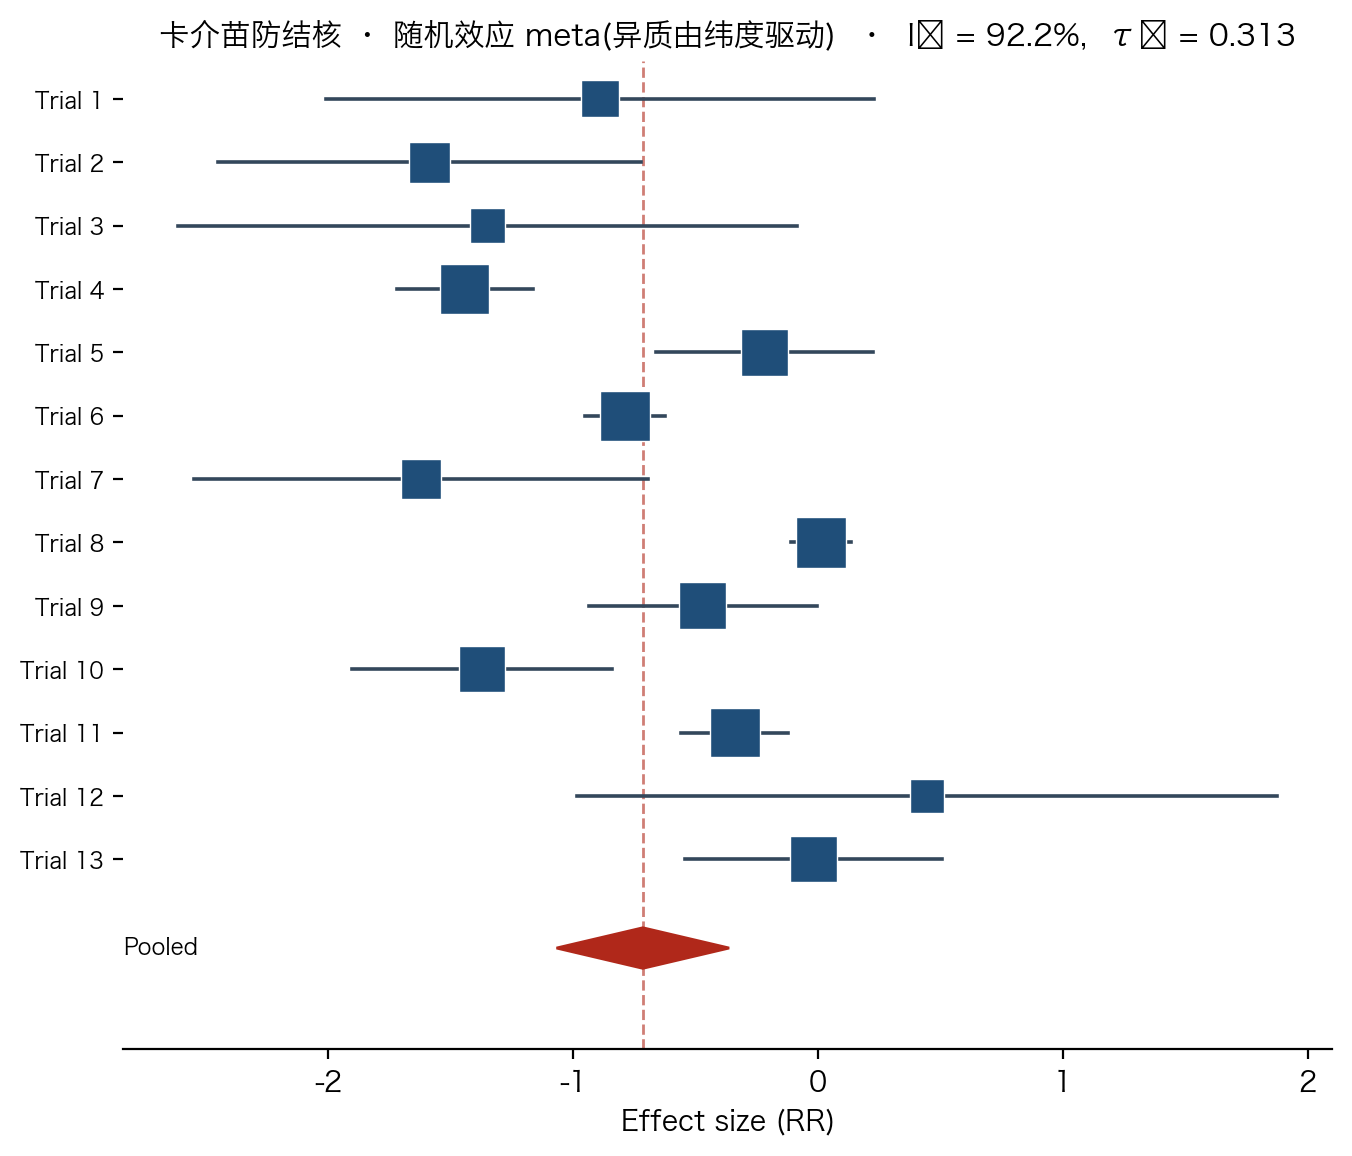

In [15]:
sv.tl.meta_random(study, method="REML")   # 森林图读随机效应合并模型
sv.pl.meta_forest(study, out="fig24_forest.png",
                  title="卡介苗防结核 · 随机效应 meta(异质由纬度驱动)")
Image("fig24_forest.png")

## 小结:从「有异质」到「异质从哪来」的证据链

这本 notebook 把「I²=92%」这个警报,一步步拆成了可辩护的结论——每一步都落在同一个
`StudyState` 上,每个数字都能追到是哪个 `sv.*` 函数、从哪份数据算出来的:

```
效应量家族  es_from_means → hedges_correct → es_convert   (SMD / g / r 同一效应三种坐标)
主数据      es_from_2x2(RR) ──▶ 效应量 + 调节变量(ablat, year)
           meta_random ──▶ 基线 I² = 92%(要被解释的总异质)
  ├─ metareg(ablat) ──────────▶ 纬度斜率显著为负,伪-R² ≈ 75%(复现 metafor)
  ├─ metareg_fdr(ablat,year) ─▶ 综合 QM 显著 + BH-FDR:纬度稳,年份共线不独立
  ├─ subgroup(高/低纬) ───────▶ Q_between 显著:亚组合并效应确实不同
  ├─ metareg_permutest ───────▶ 小 k 置换 p 佐证,不迷信正态近似
  ├─ metaforest ──────────────▶ RF 变量重要性:纬度 ≫ 年份(不预设线性)
  ├─ metareg_multimodel ──────▶ AICc + Akaike 权重:含纬度模型占满权重
  └─ ma_lrt ──────────────────▶ 似然比:加纬度显著提升似然
```

**要点**:①高异质要追来源,不能止于报告 I²;②多个调节变量**必做 FDR**;③离散调节用亚组 +
Q_between,连续调节用元回归斜率;④小 k 用**置换检验**替代大样本近似;⑤线性元回归 + `metaforest`
+ 多模型平均三管齐下,才对「变量重要性」下稳健结论;⑥始终记得元回归是**观测性**的,纬度与年代
共线,「解释」不是「因果」。

下一本([23 · 多层与稳健 meta](23_multilevel_and_robust_meta.ipynb))处理另一个棘手情形:
**每项研究贡献多个相依的效应量**——这时两层元回归会低估不确定性,需要三层 `rma_mv` 和簇稳健方差
`ma_robust`/`robu`,以及这里点到的 `metareg_permutest` 的簇版本 `ma_cwb_test`。